# 🏦 Project: Prediction of Annual Solar Energy Production for Future Installations

## 📌 Problem Statement
The goal of this project is to develop a machine learning model that predicts annual solar energy production for future installations using system characteristics and geographic information. The model helps renewable energy companies estimate expected energy output, optimize project planning, and make informed decisions regarding location, developers, and equipment.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")
print("Libraries are imported")

Libraries are imported


## 2.Load the Dataset

In [2]:
df = pd.read_csv("Solar Energy.csv")
print("Data is Loaded")
df.head()

Data is Loaded


,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


## 3. Basic Data Inspection

In [3]:
df.shape

(218115, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

In [5]:
df.dtypes.value_counts()

object     11
float64     4
int64       2
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Data Through Date                                   0
Project ID                                          3
Interconnection Date                                0
Utility                                             0
City/Town                                          58
County                                              0
Zip                                                96
Division                                        85234
Substation                                      79944
Circuit ID                                         30
Developer                                       10550
Metering Method                                   463
Estimated PV System Size (kWdc)                     0
PV System Size (kWac)                               0
Estimated Annual PV Energy Production (kWh)         0
Energy Storage System Size (kWac)              214024
Number of Projects                                  0
dtype: int64

In [7]:
df.describe()

,Zip,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
count,218019.000000,218115.000000,218115.000000,2.181150e+05,4091.000000,218115.0
mean,11751.734473,24.507977,19.065451,2.876828e+04,32.174727,1.0
std,962.129108,291.525394,211.419642,3.422042e+05,296.161116,0.0
min,10001.000000,0.010000,0.010000,1.400000e+01,0.350000,1.0
25%,11220.000000,5.270000,4.500000,6.180000e+03,5.000000,1.0
50%,11717.000000,7.130000,6.090000,8.364000e+03,7.600000,1.0
75%,12018.000000,10.240000,8.750000,1.201700e+04,10.000000,1.0
max,14905.000000,43470.000000,31500.000000,5.102682e+07,5000.000000,1.0


## 4. Drop Unnecessary columns

In [8]:
df = df.drop(columns=[
    "Project ID",
    "Data Through Date",
    "Energy Storage System Size (kWac)",
    "Estimated PV System Size (kWdc)"
])

### Why drop them?

| Column            | Reason                    |
| ----------------- | ------------------------- |
| Project ID        | identifier only           |
| Data Through Date | not useful for prediction |
| Energy Storage    | mostly missing            |
| kWdc              | almost identical to kWac  |


In [9]:
# Drop high-missing columns
df = df.drop(columns=["Division", "Substation"])

### Why drop them?
- The features Division and Substation were removed due to a high percentage of missing values (over 35%). Although these variables may provide information about grid infrastructure, the extent of missing data could introduce noise and reduce model reliability.
| Column                        | Reason                    |
| ----------------------------- | ------------------------- |
| Division, Substation          | high missing values       |

## 5.Handle Missing Values

In [10]:
df["City/Town"].fillna(df["City/Town"].mode()[0], inplace=True)
df["Zip"].fillna(df["Zip"].mode()[0], inplace=True)
df["Developer"].fillna("unknown", inplace=True)
df["Metering Method"].fillna(df["Metering Method"].mode()[0], inplace=True)
df["Circuit ID"].fillna("Unknown", inplace=True)

In [11]:
df.isnull().sum()

Interconnection Date                           0
Utility                                        0
City/Town                                      0
County                                         0
Zip                                            0
Circuit ID                                     0
Developer                                      0
Metering Method                                0
PV System Size (kWac)                          0
Estimated Annual PV Energy Production (kWh)    0
Number of Projects                             0
dtype: int64

## 6. Exploratory Data Analysis

### Target Distribution

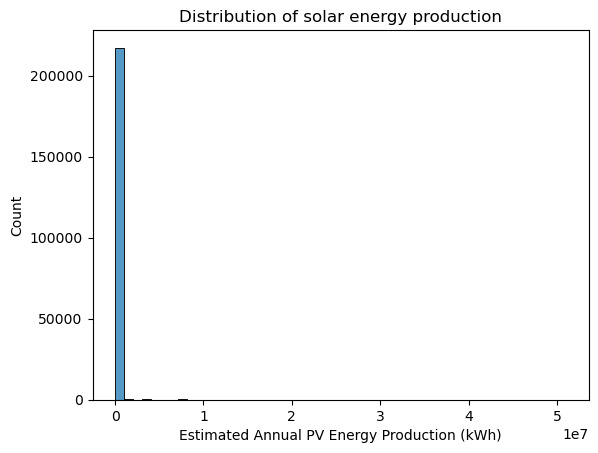

In [12]:
sns.histplot(df["Estimated Annual PV Energy Production (kWh)"], bins=50)
plt.title("Distribution of solar energy production")
plt.show()

### PV System size vs Energy Production

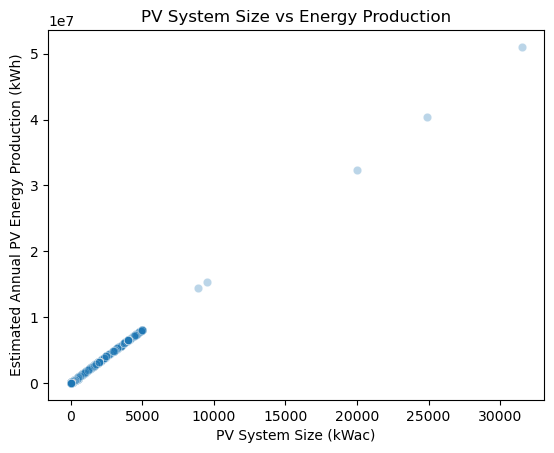

In [13]:
sns.scatterplot(
    x="PV System Size (kWac)",
    y="Estimated Annual PV Energy Production (kWh)",
    data=df,
    alpha=0.3
    )
plt.title("PV System Size vs Energy Production")
plt.show()

### Energy production by County

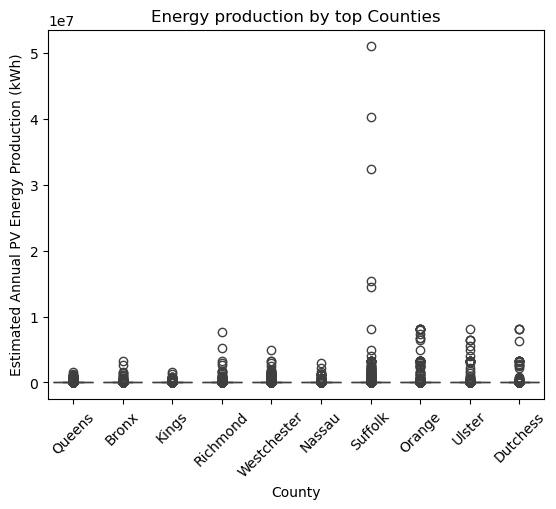

In [14]:
top_counties = df["County"].value_counts().index[:10]

sns.boxplot(
    x="County",
    y="Estimated Annual PV Energy Production (kWh)",
    data=df[df["County"].isin(top_counties)]
)

plt.xticks(rotation=45)
plt.title("Energy production by top Counties")
plt.show()

### Energy Production by Developer

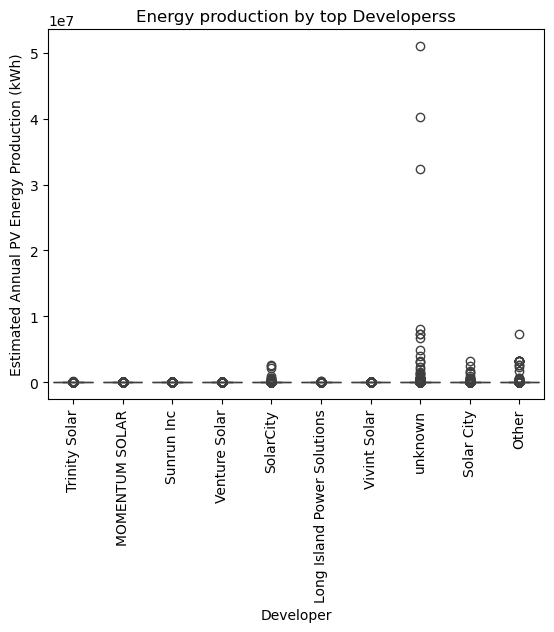

In [15]:
top_dev = df["Developer"].value_counts().index[:10]

sns.boxplot(
    x="Developer",
    y="Estimated Annual PV Energy Production (kWh)",
    data=df[df["Developer"].isin(top_dev)]
)

plt.xticks(rotation=90)
plt.title("Energy production by top Developerss")
plt.show()

### Correlation Heatmap

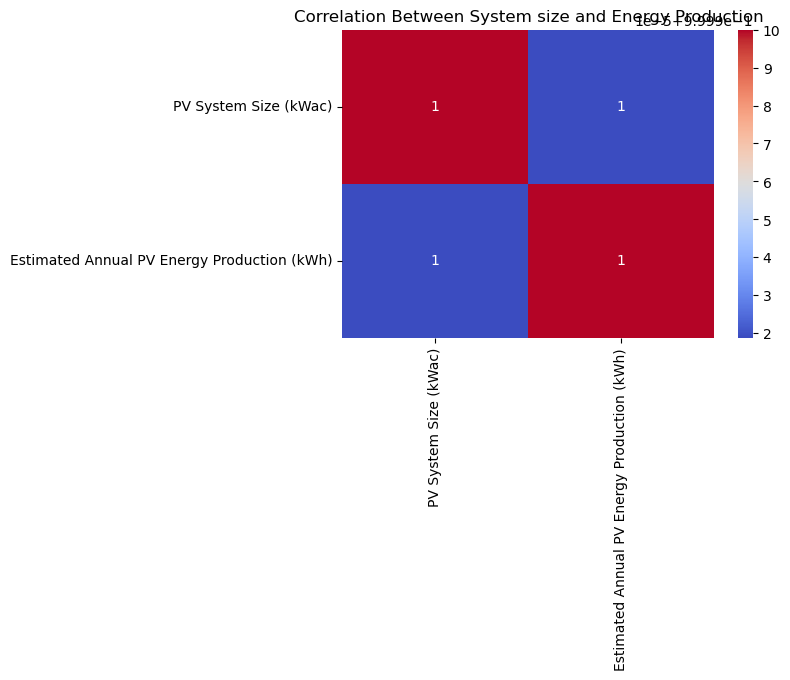

In [16]:
corr = df[[
    "PV System Size (kWac)",
    "Estimated Annual PV Energy Production (kWh)"
]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between System size and Energy Production")
plt.show()

- Exploratory data analysis was performed to understand the distribution of solar energy production and its relationship with key features such as system size, location, and developer. The analysis revealed a strong correlation between system capacity and energy production, along with variations across geographic regions and developers.

## 7. Feature Engineering

In [17]:
# Converting the installation date into usefull fearures

df["Interconnection Date"] = pd.to_datetime(df["Interconnection Date"])

df["year"] = df["Interconnection Date"].dt.year
df["month"] = df["Interconnection Date"].dt.month

df = df.drop(columns=["Interconnection Date"])

### Why this helps
instead of raw date, we extract:
- Installation yead
- Installation month

## 8.Log Transform the Target Variable

In [18]:
df["Log Energy"] = np.log1p(df["Estimated Annual PV Energy Production (kWh)"])

df = df.drop(columns=["Estimated Annual PV Energy Production (kWh)"])

In [19]:
df.columns

Index(['Utility', 'City/Town', 'County', 'Zip', 'Circuit ID', 'Developer',
       'Metering Method', 'PV System Size (kWac)', 'Number of Projects',
       'year', 'month', 'Log Energy'],
      dtype='object')

## 9.Encode Categorical Variables

In [20]:
cat_cols = [
    "Utility",
    "City/Town",
    "County",
    "Circuit ID",
    "Developer",
    "Metering Method"
]

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [21]:
df.dtypes.value_counts()

int64      7
float64    3
int32      2
Name: count, dtype: int64

## 10.Define Features and Target

In [22]:
X = df.drop(columns=["Log Energy"])
y = df["Log Energy"]

## 11.Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train["log_size"] = np.log1p(X_train["PV System Size (kWac)"])
X_test["log_size"] = np.log1p(X_test["PV System Size (kWac)"])

In [25]:
county_freq = X_train["County"].value_counts()

X_train["county_freq"] = X_train["County"].map(county_freq)
X_test["county_freq"] = X_test["County"].map(county_freq)

X_test["county_freq"].fillna(0, inplace=True)

## 12.Train the Model

### XGBoost

In [26]:
#Model
xgb = XGBRegressor(random_state=42)

#Parameter distribution
param_dist = {
    "n_estimators": randint(200, 600),
    "max_depth": randint(4, 12),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 5),
    "reg_alpha": uniform(0, 1),   # L1 regularization
    "reg_lambda": uniform(0, 1)   # L2 regularization
}

#Random Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring="r2",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

#Train
random_search.fit(X_train, y_train)

#Best Model
best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters: {'colsample_bytree': np.float64(0.7541666010159664), 'gamma': np.float64(0.07983126110107097), 'learning_rate': np.float64(0.056178765124429805), 'max_depth': 7, 'n_estimators': 566, 'reg_alpha': np.float64(0.6832635188254582), 'reg_lambda': np.float64(0.6099966577826209), 'subsample': np.float64(0.9332779646944658)}


In [27]:
pred_log = best_model.predict(X_test)

pred_energy = np.expm1(pred_log)
true_energy = np.expm1(y_test)

print("XGBoost")
print("MAE:", mean_absolute_error(true_energy, pred_energy))
print("RMSE:", np.sqrt(mean_squared_error(true_energy, pred_energy)))
print("R2:", r2_score(true_energy, pred_energy))

XGBoost
MAE: 5718.106719473304
RMSE: 126922.1114683408
R2: 0.8566930692062266


### Random Forest

In [28]:
#Model
rf = RandomForestRegressor(random_state=42)

# Parameter distribution
param_dist = {
    "n_estimators": randint(100, 300),
    "max_depth": [10, 20, None],
    "min_samples_split": randint(2, 6),
    "min_samples_leaf": randint(1, 3),
    "max_features": ["sqrt"]
}
# Random Search
rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

#Train
rf_random.fit(X_train, y_train)

#Best Model
best_rf = rf_random.best_estimator_

print("Best RF Params:", rf_random.best_params_)

Best RF Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 188}


In [29]:
pred_rf_log = best_rf.predict(X_test)

pred_energy = np.expm1(pred_rf_log)
true_energy = np.expm1(y_test)

print("Random Forest")
print("MAE:", mean_absolute_error(true_energy, pred_energy))
print("RMSE:", np.sqrt(mean_squared_error(true_energy, pred_energy)))
print("R2:", r2_score(true_energy, pred_energy))

Random Forest
MAE: 1341.868282217155
RMSE: 70537.27053281425
R2: 0.9557381136244607


## 13.Cross Validation

In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross Validation Scores: [0.99817591 0.99888638 0.99920691 0.99921866 0.99940655]
Mean CV Score: 0.9989788830713333


## 14. Dependency Check

In [31]:
# remove dominant features
X_train_no_size = X_train.drop(
    columns=["PV System Size (kWac)", "log_size"], errors='ignore'
)

X_test_no_size = X_test.drop(
    columns=["PV System Size (kWac)", "log_size"], errors='ignore'
)

rf_no_size = RandomForestRegressor(random_state=42)
rf_no_size.fit(X_train_no_size, y_train)

pred_log_no_size = rf_no_size.predict(X_test_no_size)

pred_energy_no_size = np.expm1(pred_log_no_size)

print("R2 without size:", r2_score(true_energy, pred_energy_no_size))

R2 without size: 0.7156204920633193


## Feature Importance

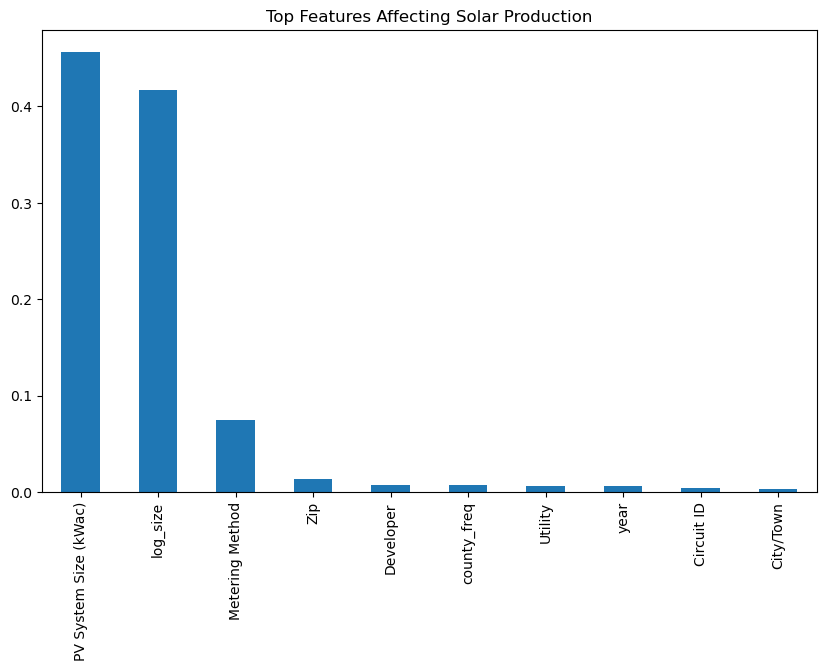

In [33]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

importance.head(10).plot(kind="bar", figsize=(10,6))
plt.title("Top Features Affecting Solar Production")
plt.show()

### Visualize Predictions

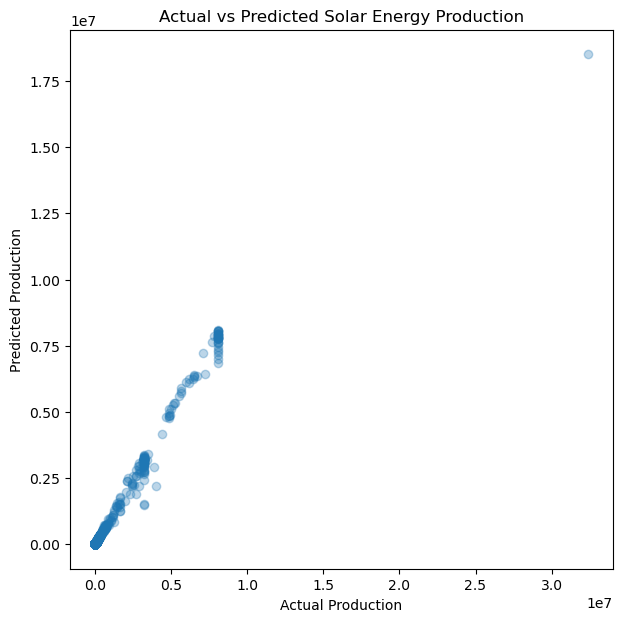

In [34]:
plt.figure(figsize=(7,7))
plt.scatter(true_energy, pred_energy, alpha=0.3)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Solar Energy Production")
plt.show()

In [35]:
sample = X_test.iloc[0:1]
prediction = best_rf.predict(sample)
pred_kwh = np.expm1(prediction)
print("Predicted Annual Solar Production:", pred_kwh)

Predicted Annual Solar Production: [5480.79308462]


### 💼 ✅ Business Insights

#### 1️⃣ System Size is the Primary Driver
- Energy production is heavily dependent on PV system capacity
- Proper system sizing is critical for maximizing output

#### 2️⃣ Location Adds Competitive Advantage
- Even without system size, model retains predictive power (R² ≈ 0.71)
- Indicates geographic factors significantly influence performance

#### 3️⃣ Developer & Operational Factors Matter
- Features like developer and metering method contribute to variation
- Suggests impact of installation quality and system configuration

#### 4️⃣ Reliable Predictions for Planning
- High accuracy + cross-validation stability
- Enables trustworthy forecasting before installation

#### 5️⃣ Improved Investment Decisions
- Accurate energy prediction → better ROI estimation
- Helps prioritize high-performing projects and locations

#### 6️⃣ Beyond Single-Feature Dependency
- Although system size dominates, the model demonstrates that multiple factors influence solar production,
making the analysis more robust and practically valuable.

### Conclusion

### 📌 ✅ Final Conclusion

In this project, a machine learning model was developed to predict annual solar energy production using key features such as system size, location, developer, and operational characteristics.

Multiple models were trained and evaluated, including XGBoost and Random Forest. The Random Forest model outperformed XGBoost, achieving an R² score of approximately 0.956, indicating that the model can explain around 95.6% of the variation in solar energy production.

- Random Forest achieved the best performance (R² ≈ 0.96)
- Cross-validation confirmed the model is stable and reliable (mean R² ≈ 0.999)
- Feature importance and dependency analysis showed that:
- PV System Size is the dominant factor

<div style="background-color:#f0f0f0; padding:15px; color:#2e86c1; font-size:24px; font-weight:bold; text-align:center;">
    <b>Thank you<b/>
</div>